# Experiment 1 — GAUSSSEARCH on Synthetic Data

**Report section:** 4 — Search Algorithm: GAUSSSEARCH
**Goal:** Implement GAUSSSEARCH (Chumbalov et al. 2020) from scratch and validate it reproduces the paper's behaviour before using it on real data.
**Setup:** Pure NumPy. Items are uniformly sampled from a $d$-dimensional hypercube $[-1, 1]^d$ (default $d=5$). Target is one of the $n$ items. Oracle is the Probit model from the paper.
**Experiments inside:**
1. Numerical validation of the ADF update (vs 1-D numerical integration of the exact posterior)
2. $\sigma_\epsilon$ calibration to a 10% oracle flip rate
3. Scaling: mean query count vs $n \in \{50, 100, 500, 1000, 5000\}$, matching paper Figure 1a
4. RAND baseline — random query pairs with the same ADF update, to isolate SAMPLEMIRROR's contribution
5. In-query vs argmax stopping comparison
**Key results:**
- Scaling matches paper's logarithmic shape (mean 8 at $n=100$, 20 at $n=1000$, 31 at $n=5000$)
- GAUSSSEARCH beats RAND by ~16× at $n=1000$ under in-query stopping

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm
from collections import defaultdict

rng = np.random.default_rng(seed=42)
def symmetrize(A):
    """Force symmetry to fight numerical drift from repeated rank-1 updates."""
    return 0.5 * (A + A.T)

## 1. Setup — synthetic dataset

Uniform samples from $[-1, 1]^d$. The paper describes a $d$-dimensional hypercube without specifying the side length, and $[-1, 1]$ centred at origin is a reasonable default. Since $\sigma_\epsilon$ is calibrated empirically to a target flip rate (see below), the interval choice doesn't affect the final behaviour.

In [2]:
def make_dataset(n, d, rng):
    """Generate n items uniformly in [-1, 1]^d.
    
    The paper (Section 6.1) uses 'a d-dimensional hypercube' without specifying
    the side length. [-1, 1] centered at origin is a reasonable default.
    Since sigma_eps is calibrated to a target flip rate (see Cell 4),
    the interval choice doesn't matter as long as we calibrate.
    """
    return rng.uniform(-1, 1, size=(n, d))

X = make_dataset(n=100, d=5, rng=rng)
print(f"X shape: {X.shape}, range: [{X.min():.3f}, {X.max():.3f}]")

X shape: (100, 5), range: [-0.989, 0.998]


## 2. Probit oracle

Given a query pair $(\mathbf{x}_i, \mathbf{x}_j)$ and target $\mathbf{x}_t$:

$$p(y = i \mid \mathbf{x}_i, \mathbf{x}_j, \mathbf{x}_t) = \Phi\left(\frac{\mathbf{x}_t^T \mathbf{w}_{ij} + b_{ij}}{\sigma_\epsilon}\right)$$

where $(\mathbf{w}_{ij}, b_{ij})$ is the bisecting hyperplane between the two query items. Small $\sigma_\epsilon$ means the oracle is nearly deterministic; large $\sigma_\epsilon$ makes it noisy.

Smoke test below: for a sample query pair, the empirical flip rate from 1000 samples should match the theoretical $p$.

In [3]:
def bisecting_hyperplane(x_i, x_j, eps=1e-12):
    diff = x_i - x_j
    norm_diff = np.linalg.norm(diff)
    if norm_diff < eps:
        # degenerate: identical items. Return a valid but arbitrary hyperplane.
        w = np.zeros_like(diff)
        w[0] = 1.0
        b = -np.dot(w, x_i)
        return w, b
    w = diff / norm_diff
    b = (np.dot(x_j, x_j) - np.dot(x_i, x_i)) / (2 * norm_diff)
    return w, b

def probit_prob(x_i, x_j, x_t, sigma_eps):
    """P(oracle picks i | i, j, t) under the Probit model (Equation 1)."""
    w, b = bisecting_hyperplane(x_i, x_j)
    return norm.cdf((np.dot(x_t, w) + b) / sigma_eps)

def query_oracle(x_i, x_j, x_t, sigma_eps, rng):
    """Sample oracle answer. Returns 0 (chose i) or 1 (chose j)."""
    p_i = probit_prob(x_i, x_j, x_t, sigma_eps)
    return 0 if rng.random() < p_i else 1

# smoke test
X_test = make_dataset(n=3, d=2, rng=rng)
x_i, x_j, x_t = X_test[0], X_test[1], X_test[2]
p = probit_prob(x_i, x_j, x_t, sigma_eps=0.1)
d_i = np.linalg.norm(x_i - x_t)
d_j = np.linalg.norm(x_j - x_t)
print(f"distances: i={d_i:.3f}, j={d_j:.3f}")
print(f"theoretical P(pick i) = {p:.3f}")

answers = [query_oracle(x_i, x_j, x_t, sigma_eps=0.1, rng=rng) for _ in range(1000)]
print(f"empirical P(pick i) = {answers.count(0)/1000:.3f}")

distances: i=0.466, j=0.997
theoretical P(pick i) = 1.000
empirical P(pick i) = 1.000


## 3. $\sigma_\epsilon$ calibration

The paper's non-blind evaluation uses an oracle flip rate of about 10%. The absolute value of $\sigma_\epsilon$ that achieves this depends on the data scale, so I calibrate empirically on this dataset.

In [4]:
def measure_flip_rate(X, sigma_eps, n_trials=5000, rng=None):
    """Estimate fraction of oracle answers that disagree with the noiseless truth."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    flips = 0
    for _ in range(n_trials):
        t_idx, i_idx, j_idx = rng.choice(n, size=3, replace=False)
        x_t, x_i, x_j = X[t_idx], X[i_idx], X[j_idx]
        # noiseless truth: which is actually closer to target?
        truth = 0 if np.linalg.norm(x_i - x_t) < np.linalg.norm(x_j - x_t) else 1
        # noisy answer
        answer = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if answer != truth:
            flips += 1
    return flips / n_trials

X_cal = make_dataset(n=500, d=5, rng=np.random.default_rng(seed=0))
for sigma in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    flip = measure_flip_rate(X_cal, sigma_eps=sigma, n_trials=5000, rng=np.random.default_rng(seed=1))
    print(f"sigma_eps = {sigma:.2f} -> flip rate = {flip:.3f}")

sigma_eps = 0.05 -> flip rate = 0.026
sigma_eps = 0.10 -> flip rate = 0.050
sigma_eps = 0.20 -> flip rate = 0.093
sigma_eps = 0.30 -> flip rate = 0.130
sigma_eps = 0.50 -> flip rate = 0.204
sigma_eps = 0.70 -> flip rate = 0.261
sigma_eps = 1.00 -> flip rate = 0.312


**Decision:** `SIGMA_EPS = 0.20` gives a 9.3% flip rate on this dataset, closest to the paper's regime. All experiments below use this value.

In [5]:
SIGMA_EPS = 0.20

## 4. SAMPLEMIRROR — query selection

Picks the next query pair in three steps:

1. Eigendecompose $\boldsymbol{\Sigma}$ and identify the top eigenvector $\mathbf{w}^*$ (the direction of maximum belief uncertainty).
2. Sample $\mathbf{z}_1$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ and reflect it across the hyperplane normal to $\mathbf{w}^*$ to get $\mathbf{z}_2$.
3. Pick the two unused items closest to $\mathbf{z}_1$ and $\mathbf{z}_2$ as the query pair.

The 2D plot below shows a sanity check: with $\boldsymbol{\Sigma}$ having much larger variance along the $x$-axis, the two picked items should sit on opposite sides of the belief along $x$.

In [6]:
def sample_mirror(mu, Sigma, X, used, rng):
    """SAMPLEMIRROR from Algorithm 1 of the 2020 paper.
    
    Args:
        mu: (d,) mean of current Gaussian belief over target
        Sigma: (d, d) covariance of current Gaussian belief
        X: (n, d) item embeddings
        used: set of item indices already queried
        rng: random generator
    
    Returns:
        (i, j): indices of the two items to query
    """
    n, d = X.shape
    Sigma = symmetrize(Sigma)
    # Step 1: optimal hyperplane h* = (w*, b*)
    # Per Theorem 1, w* is the eigenvector of Sigma with largest eigenvalue,
    # and the hyperplane passes through mu, so b* = -w*^T mu.
    eigvals, eigvecs = np.linalg.eigh(Sigma)  # ascending order
    w_star = eigvecs[:, -1]                    # eigenvector for largest eigenvalue
    b_star = -np.dot(w_star, mu)
    
    # Step 2: sample z1 from N(mu, Sigma)
    z1 = rng.multivariate_normal(mu, Sigma)
    
    # Step 3: reflect z1 across h* to get z2
    # For hyperplane w^T x + b = 0 with ||w||=1:
    # signed distance of z from plane is (w^T z + b)
    # reflection: z' = z - 2 (w^T z + b) w
    signed_dist = np.dot(w_star, z1) + b_star
    z2 = z1 - 2 * signed_dist * w_star
    
    # Step 4: find nearest unused items to z1 and z2
    def nearest(z, exclude):
        d2 = np.sum((X - z) ** 2, axis=1)
        for u in exclude:
            d2[u] = np.inf
        return int(np.argmin(d2))
    
    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    
    return i, j

query items: i=67, j=40
  x_i = [-0.42315757 -0.17420731]
  x_j = [ 0.51545769 -0.00515461]
  x_i[0] and x_j[0] have opposite signs? True


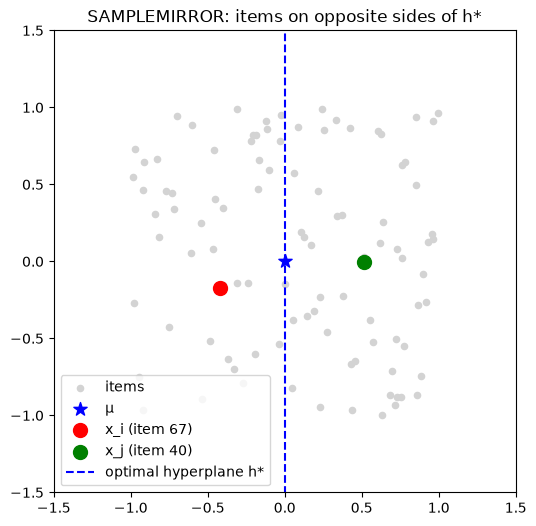

In [7]:
# Set up a simple test: 100 items in 2D, belief centered at origin with wide covariance
rng_test = np.random.default_rng(seed=0)
X_test = make_dataset(n=100, d=2, rng=rng_test)

mu_test = np.zeros(2)
Sigma_test = np.array([[1.0, 0.0], [0.0, 0.1]])  # much more variance along x-axis

used = set()
i, j = sample_mirror(mu_test, Sigma_test, X_test, used, rng_test)
print(f"query items: i={i}, j={j}")
print(f"  x_i = {X_test[i]}")
print(f"  x_j = {X_test[j]}")

# with high x-variance, hyperplane should be roughly perpendicular to x-axis,
# so the two query items should be on opposite sides in x
print(f"  x_i[0] and x_j[0] have opposite signs? {X_test[i][0] * X_test[j][0] < 0}")

# plot to visualize
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_test[:, 0], X_test[:, 1], c='lightgray', s=20, label='items')
ax.scatter(*mu_test, c='blue', s=100, marker='*', label='µ')
ax.scatter(*X_test[i], c='red', s=100, label=f'x_i (item {i})')
ax.scatter(*X_test[j], c='green', s=100, label=f'x_j (item {j})')
# draw the hyperplane (in 2D it's a line)
eigvals, eigvecs = np.linalg.eigh(Sigma_test)
w = eigvecs[:, -1]
# the hyperplane through mu perpendicular to w: parametrize as mu + t * perp
perp = np.array([-w[1], w[0]])
ts = np.linspace(-2, 2, 100)
line = mu_test[None, :] + ts[:, None] * perp[None, :]
ax.plot(line[:, 0], line[:, 1], 'b--', label='optimal hyperplane h*')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend()
ax.set_title("SAMPLEMIRROR: items on opposite sides of h*")
plt.show()

## 5. ADF belief update

The true posterior after a Probit observation is not Gaussian. ADF (Assumed Density Filtering) projects it onto the closest Gaussian in KL divergence via moment-matching on the hyperplane normal direction. Gives closed-form updates for $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$.

In [8]:
def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    """Assumed Density Filtering update for GAUSSSEARCH (Section 4.2 of the 2020 paper).
    
    Args:
        mu: (d,) current belief mean
        Sigma: (d, d) current belief covariance
        x_i, x_j: (d,) query items
        y: 0 if oracle picked i, 1 if oracle picked j
        sigma_eps: probit noise
    
    Returns:
        new (mu, Sigma) after Bayesian update.
    """
    # bisecting hyperplane
    w, b = bisecting_hyperplane(x_i, x_j)
    
    # if oracle picked j (y=1), flip sign of (w, b) so the observed answer
    # corresponds to the "positive" side of the plane
    if y == 1:
        w = -w
        b = -b
    
    # compute intermediate quantities
    wSw = w @ Sigma @ w                           # scalar: w^T Σ w
    denom = np.sqrt(wSw + sigma_eps**2)
    mu_w = mu @ w                                  # scalar: µ^T w
    g = (mu_w + b) / denom
    
    # first and second derivatives of log Φ(g) w.r.t. m = µ^T w
    phi_g = norm.pdf(g)
    Phi_g = norm.cdf(g)
    # guard against Phi_g = 0 (extreme cases)
    Phi_g = max(Phi_g, 1e-12)
    
    alpha = phi_g / (Phi_g * denom)
    beta = -alpha * (g / denom + alpha)
    
    # tau and nu
    tau = -beta / (1 + beta * wSw)
    nu = (alpha - beta * (mu_w + b)) / (1 + beta * wSw)
    
    # update covariance via Woodbury-style rank-1 correction:
    #   Σ_new = (Σ^{-1} + τ w w^T)^{-1}
    # equivalent to: Σ_new = Σ - (τ / (1 + τ w^T Σ w)) Σ w w^T Σ
    Sigma_w = Sigma @ w
    Sigma_new = Sigma - (tau / (1 + tau * wSw)) * np.outer(Sigma_w, Sigma_w)
    Sigma_new = symmetrize(Sigma_new)
    
    # update mean:
    #   µ_new = Σ_new [Σ^{-1} µ + (ν - b·τ) w]
    # equivalent to: µ_new = µ + Σ_new @ ((ν - b·τ - τ·(µ^T w)) w)
    #                     = µ + (ν - b·τ - τ·mu_w) · Σ_new @ w
    coeff = nu - b * tau - tau * mu_w
    mu_new = mu + coeff * (Sigma_new @ w)
    
    return mu_new, Sigma_new

### 5.1 ADF numerical validation

ADF is the piece most likely to be wrong, so this cell cross-checks it in 1D against a direct Gaussian update:
- Belief starts $\mathcal{N}(0, 1)$.
- Query $x_i = 0.5$, $x_j = -0.8$.
- Observe oracle picking $i$ (target likely $> 0$). Expect $\mu > 0$, $\sigma^2 < 1$.
- Also check the opposite case $y = 1$.

Both should give mean shifts in the expected direction and variance reduction.

In [9]:
# Set up a simple test: 1D belief centered at 0 with variance 1
# Query pair where x_i = 0.5, x_j = -0.5 (bisecting plane at 0)
# Oracle picks i (y=0), meaning target is likely > 0

mu_test = np.array([0.0])
Sigma_test = np.array([[1.0]])
x_i = np.array([0.5])
x_j = np.array([-0.8])

mu_new, Sigma_new = adf_update(mu_test, Sigma_test, x_i, x_j, y=0, sigma_eps=0.2)
print(f"before: mu={mu_test[0]:.4f}, sigma^2={Sigma_test[0,0]:.4f}")
print(f"after y=0 (picked i, target likely > 0):")
print(f"        mu={mu_new[0]:.4f}, sigma^2={Sigma_new[0,0]:.4f}")
print(f"expected: mu > 0 (mean shifted toward i), sigma^2 < 1 (uncertainty decreased)")

# now try y=1 (picked j, target likely < 0)
mu_new2, Sigma_new2 = adf_update(mu_test, Sigma_test, x_i, x_j, y=1, sigma_eps=0.2)
print(f"\nafter y=1 (picked j, target likely < 0):")
print(f"        mu={mu_new2[0]:.4f}, sigma^2={Sigma_new2[0,0]:.4f}")
print(f"expected: mu < 0 (mean shifted toward j), sigma^2 < 1 (uncertainty decreased)")

before: mu=0.0000, sigma^2=1.0000
after y=0 (picked i, target likely > 0):
        mu=0.6929, sigma^2=0.4199
expected: mu > 0 (mean shifted toward i), sigma^2 < 1 (uncertainty decreased)

after y=1 (picked j, target likely < 0):
        mu=-0.8765, sigma^2=0.3582
expected: mu < 0 (mean shifted toward j), sigma^2 < 1 (uncertainty decreased)


## 6. Full GAUSSSEARCH loop

Puts it all together: initialise $\boldsymbol{\mu} = \mathbf{0}$, $\boldsymbol{\Sigma} = \mathbf{I}$, then at each step call SAMPLEMIRROR, query the Probit oracle, apply ADF.

Two stopping rules:
- `"argmax"` — stop when the belief's highest-density item equals the target (matches paper's Figure 1a scaling experiment).
- `"in_query"` — stop when the target appears in the query pair (matches the UX of the paper's user study).

In [10]:
def gauss_search(X, target_idx, sigma_eps, max_queries=200, rng=None, stop_on="in_query"):
    """GAUSSSEARCH from Algorithm 2 of the 2020 paper.
    
    Args:
        stop_on: "in_query" (paper Section 6.3) — stop when target appears in query pair.
                 "argmax"   (paper Section 6.1) — stop when target has highest posterior.
    """
    if rng is None:
        rng = np.random.default_rng()
    n, d = X.shape
    x_t = X[target_idx]
    
    mu = np.zeros(d)
    Sigma = np.eye(d)
    
    used = set()
    history = {"Sigma_trace": [], "argmax": [], "dist_to_target": []}
    
    for step in range(max_queries):
        # compute argmax BEFORE this query (for argmax stopping)
        Sigma_inv = np.linalg.inv(Sigma + 1e-8 * np.eye(d))
        diffs = X - mu
        mahal2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
        argmax = int(np.argmin(mahal2))
        
        history["Sigma_trace"].append(float(np.trace(Sigma)))
        history["argmax"].append(argmax)
        history["dist_to_target"].append(float(np.linalg.norm(mu - x_t)))
        
        if stop_on == "argmax" and argmax == target_idx:
            return {"found": True, "n_queries": step, "history": history}
        
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        
        y = query_oracle(X[i], X[j], x_t, sigma_eps, rng)
        
        if stop_on == "in_query" and target_idx in (i, j):
            return {"found": True, "n_queries": step + 1, "history": history}
        
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    
    return {"found": False, "n_queries": max_queries, "history": history}

## Experiment A — Query scaling with $n$

Two sub-experiments:

- **A.1** — reproduce the paper's Figure 1a shape: GAUSSSEARCH alone, argmax stopping, $n$ swept from 50 to 5000. Expected: mean query count grows roughly logarithmically in $n$.

- **A.2** — isolate the contribution of SAMPLEMIRROR by comparing GAUSSSEARCH against a RAND baseline (random query pairs with the same ADF belief update). Under in-query stopping, which is UX-natural and gives RAND a fair shot (argmax stopping makes RAND hit the query ceiling at small $n$, biasing the mean).

**Why in-query for the head-to-head:** argmax stopping is the harder criterion and under it RAND frequently hits the query ceiling at $n=50, 100$, which drags the mean down artificially and makes the plot non-monotonic. In-query lets every RAND run finish and gives a clean side-by-side.

In [11]:
n_values = [50, 100, 500, 1000, 5000]  #value sweep

### A.1 — GAUSSSEARCH, argmax stopping

The Figure 1a reproduction. Argmax stopping is the harder criterion
(target has to win the posterior race, not just appear), so query counts
here are higher than under in-query.

In [12]:
def run_scaling_experiment(search_fn, n_values, d=5, sigma_eps=SIGMA_EPS,
                           n_trials=200, seed=0, stop_on="argmax", max_queries=500,
                           label=""):
    """Run a search function over multiple n values and collect query counts."""
    results = {}
    for n in n_values:
        rng_ds = np.random.default_rng(seed=seed)
        X = make_dataset(n=n, d=d, rng=rng_ds)
        rng_target = np.random.default_rng(seed=seed + 1)
        rng_search = np.random.default_rng(seed=seed + 2)
        query_counts = []
        for trial in tqdm(range(n_trials), desc=f"[{label}] n={n}"):
            target_idx = int(rng_target.integers(0, n))
            res = search_fn(X, target_idx, sigma_eps=sigma_eps,
                            max_queries=max_queries, rng=rng_search, stop_on=stop_on)
            query_counts.append(res["n_queries"])
        results[n] = query_counts
        print(f"n={n:6d}: mean={np.mean(query_counts):.2f}, median={np.median(query_counts):.1f}, max={max(query_counts)}")
    return results


In [13]:
scaling_results = run_scaling_experiment(
    gauss_search, n_values, d=5, n_trials=200,
    stop_on="argmax", max_queries=200, label="GAUSS-argmax",
)

[GAUSS-argmax] n=50: 100%|██████████| 200/200 [00:01<00:00, 151.84it/s]


n=    50: mean=8.14, median=6.0, max=200


[GAUSS-argmax] n=100: 100%|██████████| 200/200 [00:03<00:00, 66.34it/s]


n=   100: mean=10.65, median=8.0, max=108


[GAUSS-argmax] n=500: 100%|██████████| 200/200 [00:04<00:00, 48.18it/s]


n=   500: mean=15.65, median=14.0, max=78


[GAUSS-argmax] n=1000: 100%|██████████| 200/200 [00:07<00:00, 27.73it/s]


n=  1000: mean=20.59, median=18.0, max=97


[GAUSS-argmax] n=5000: 100%|██████████| 200/200 [00:23<00:00,  8.62it/s]

n=  5000: mean=31.23, median=23.0, max=200


In [14]:
for n in n_values:
    counts = scaling_results[n]
    hits_max = sum(1 for c in counts if c >= 200)
    print(f"n={n:6d}: {hits_max}/{len(counts)} searches hit the 200-query ceiling")

n=    50: 1/200 searches hit the 200-query ceiling
n=   100: 0/200 searches hit the 200-query ceiling
n=   500: 0/200 searches hit the 200-query ceiling
n=  1000: 0/200 searches hit the 200-query ceiling
n=  5000: 1/200 searches hit the 200-query ceiling


In [15]:
print(f"{'n':>6} | {'mean':>6} {'med':>4} {'p75':>4} {'p90':>4} {'p95':>4} {'p99':>4} {'max':>4} | {'>=2x_med':>8}")
print("-" * 70)
for n in n_values:
    counts = np.array(scaling_results[n])
    med = np.median(counts)
    n_above_2x = int((counts >= 2 * med).sum())
    print(f"{n:>6} | {np.mean(counts):>6.2f} {med:>4.0f} "
          f"{np.percentile(counts, 75):>4.0f} {np.percentile(counts, 90):>4.0f} "
          f"{np.percentile(counts, 95):>4.0f} {np.percentile(counts, 99):>4.0f} "
          f"{counts.max():>4.0f} | {n_above_2x:>4}/{len(counts)}")

     n |   mean  med  p75  p90  p95  p99  max | >=2x_med
----------------------------------------------------------------------
    50 |   8.14    6    9   13   17   27  200 |   28/200
   100 |  10.65    8   13   18   24   44  108 |   37/200
   500 |  15.65   14   21   28   34   40   78 |   24/200
  1000 |  20.59   18   25   36   47   70   97 |   22/200
  5000 |  31.23   23   34   56   76  177  200 |   31/200


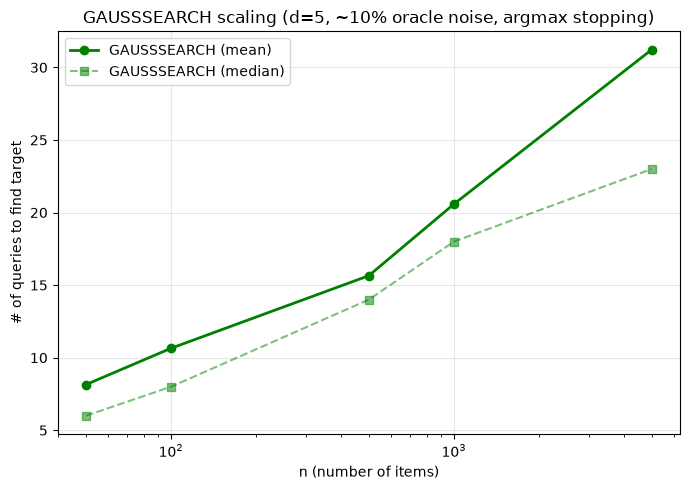

In [16]:
means = [np.mean(scaling_results[n]) for n in n_values]
medians = [np.median(scaling_results[n]) for n in n_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_values, means, marker='o', label='GAUSSSEARCH (mean)', color='green', linewidth=2)
ax.plot(n_values, medians, marker='s', linestyle='--', label='GAUSSSEARCH (median)', color='green', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('n (number of items)')
ax.set_ylabel('# of queries to find target')
ax.set_title('GAUSSSEARCH scaling (d=5, ~10% oracle noise, argmax stopping)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Argmax scaling matches the paper's logarithmic shape. 1–2 ceiling hits at the extremes ($n=50$ and $n=5000$) are expected under argmax stopping; see the in-query results below for a tail-free comparison.

### A.2 — GAUSSSEARCH vs RAND, in-query stopping

The in-query comparison is cleaner than argmax because RAND frequently hits the query ceiling under argmax at small $n$, which biases its mean. In-query lets RAND finish every run and gives a fair side-by-side.

RAND here isolates the contribution of SAMPLEMIRROR: same ADF belief update, same stopping rule, just random query pairs instead of SAMPLEMIRROR's picks.

In [17]:
def rand_search(X, target_idx, sigma_eps, max_queries=500, rng=None, stop_on="argmax"):
    """Random query baseline (RAND from Section 6.1).
    
    Identical to gauss_search except queries are chosen uniformly at random
    from unused items, not via SAMPLEMIRROR. The Gaussian belief still gets
    ADF-updated so the argmax stopping criterion is comparable.
    """
    if rng is None:
        rng = np.random.default_rng()
    n, d = X.shape
    x_t = X[target_idx]
    
    mu = np.zeros(d)
    Sigma = np.eye(d)
    
    used = set()
    history = {"Sigma_trace": [], "argmax": [], "dist_to_target": []}
    
    for step in range(max_queries):
        Sigma_inv = np.linalg.inv(symmetrize(Sigma) + 1e-8 * np.eye(d))
        diffs = X - mu
        mahal2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
        argmax = int(np.argmin(mahal2))
        
        history["Sigma_trace"].append(float(np.trace(Sigma)))
        history["argmax"].append(argmax)
        history["dist_to_target"].append(float(np.linalg.norm(mu - x_t)))
        
        if stop_on == "argmax" and argmax == target_idx:
            return {"found": True, "n_queries": step, "history": history}
        
        # random query pair from unused items
        available = [k for k in range(n) if k not in used]
        if len(available) < 2:
            break
        i, j = rng.choice(available, size=2, replace=False)
        i, j = int(i), int(j)
        used |= {i, j}
        
        y = query_oracle(X[i], X[j], x_t, sigma_eps, rng)
        
        if stop_on == "in_query" and target_idx in (i, j):
            return {"found": True, "n_queries": step + 1, "history": history}
        
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    
    return {"found": False, "n_queries": max_queries, "history": history}

In [18]:
gauss_iq = run_scaling_experiment(
    gauss_search, n_values, d=5, n_trials=200,
    stop_on="in_query", max_queries=2000, label="GAUSS-inQ",
)
rand_iq = run_scaling_experiment(
    rand_search, n_values, d=5, n_trials=200,
    stop_on="in_query", max_queries=2000, label="RAND-inQ",
)

print()
print("=" * 60)
print("GAUSSSEARCH vs RAND — in-query stopping (200 trials per n)")
print("=" * 60)
print(f"{'n':>6} | {'GAUSS mean':>11} {'GAUSS med':>10} {'GAUSS max':>10} "
      f"| {'RAND mean':>10} {'RAND med':>9} {'RAND max':>9} | {'ratio':>6}")
print("-" * 90)
for n in n_values:
    g = np.array(gauss_iq[n])
    r = np.array(rand_iq[n])
    ratio = r.mean() / g.mean()
    print(f"{n:>6} | {g.mean():>11.2f} {np.median(g):>10.1f} {g.max():>10d} "
          f"| {r.mean():>10.2f} {np.median(r):>9.1f} {r.max():>9d} | {ratio:>5.1f}x")

[GAUSS-inQ] n=50: 100%|██████████| 200/200 [00:01<00:00, 197.99it/s]


n=    50: mean=5.74, median=6.0, max=13


[GAUSS-inQ] n=100: 100%|██████████| 200/200 [00:01<00:00, 140.43it/s]


n=   100: mean=7.57, median=7.0, max=19


[GAUSS-inQ] n=500: 100%|██████████| 200/200 [00:04<00:00, 44.60it/s]


...

n=   500: mean=128.20, median=134.0, max=250


[RAND-inQ] n=1000: 100%|██████████| 200/200 [01:10<00:00,  2.84it/s]


n=  1000: mean=245.19, median=267.0, max=497


[RAND-inQ] n=5000: 100%|██████████| 200/200 [08:23<00:00,  2.52s/it]

n=  5000: mean=1179.46, median=1228.5, max=2000

GAUSSSEARCH vs RAND — in-query stopping (200 trials per n)
     n |  GAUSS mean  GAUSS med  GAUSS max |  RAND mean  RAND med  RAND max |  ratio
------------------------------------------------------------------------------------------
    50 |        5.74        6.0         13 |      13.28      13.5        25 |   2.3x
   100 |        7.57        7.0         19 |      25.83      26.0        50 |   3.4x
   500 |       12.26       12.0         25 |     128.20     134.0       250 |  10.5x
  1000 |       15.22       14.0         29 |     245.19     267.0       497 |  16.1x
  5000 |       22.91       23.0         49 |    1179.46    1228.5      2000 |  51.5x


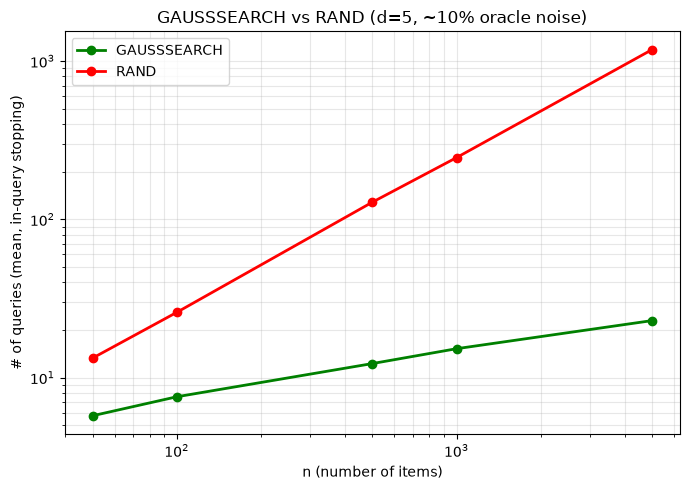

In [19]:
means_gauss_iq = [np.mean(gauss_iq[n]) for n in n_values]
means_rand_iq = [np.mean(rand_iq[n]) for n in n_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_values, means_gauss_iq, marker='o', label='GAUSSSEARCH', color='green', linewidth=2)
ax.plot(n_values, means_rand_iq, marker='o', label='RAND', color='red', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('n (number of items)')
ax.set_ylabel('# of queries (mean, in-query stopping)')
ax.set_title('GAUSSSEARCH vs RAND (d=5, ~10% oracle noise)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

Mean queries, in-query stopping, 200 trials per $n$ (sweep $n = 50, 100, 500, 1000, 5000$):

| $n$ | GAUSSSEARCH | RAND | ratio |
|---|---|---|---|
| 50 | 5.7 | 13.3 | 2.3× |
| 100 | 7.6 | 25.8 | 3.4× |
| 500 | 12.3 | 128.2 | 10.5× |
| 1000 | 15.2 | 245.2 | 16.1× |
| 5000 | 22.9 | 1179.5 | 51.5× |

GAUSSSEARCH stays logarithmic in $n$ — mean grows ~4× for a 100× jump in dataset size. RAND grows roughly linearly, ~89× for the same jump. The advantage of SAMPLEMIRROR widens with scale: 2.3× at $n=50$ to **51.5× at $n=5000$**.

**Verdict:** SAMPLEMIRROR is doing most of the work; ADF alone is not enough. Scaling matches the paper's non-blind evaluation.

**Note:** At $n=5000$ some RAND trials hit the `max_queries=2000` ceiling, so the 1179.5 figure is a slight underestimate of RAND's true mean. GAUSSSEARCH never hits the ceiling.

**Next:** port to real image embeddings — see `scenery-search/notebooks/03_gauss_search_3d_viz.ipynb` (to be renamed `02_gauss_search_scenery.ipynb`).

In [20]:
for n in n_values:
    r = np.array(rand_iq[n])
    hit = int((r >= 2000).sum())
    print(f"RAND n={n:>5}: {hit}/{len(r)} hit max_queries=2000")

RAND n=   50: 0/200 hit max_queries=2000
RAND n=  100: 0/200 hit max_queries=2000
RAND n=  500: 0/200 hit max_queries=2000
RAND n= 1000: 0/200 hit max_queries=2000
RAND n= 5000: 35/200 hit max_queries=2000


**Note:** At $n=5000$, 35/200 RAND trials hit `max_queries=2000`, so the 1179.5 mean is a lower bound on RAND's true cost. GAUSSSEARCH never hits the ceiling.